# Продуктовый анализ интернет-магазина
## Очистка данных и EDA

**Контекст:** Анализ транзакций британского интернет-магазина. 
- **Цель** — найти точки роста через анализ удержания и сегментацию клиентов. В данном ноутбуке будет реализованы очистка, EDA, расчёт основных метрик, и выявление трендов.
- **Данные:** E-commerce Data (Online Retail), UCI ML Repository. Датасет скачан с ресурса Kaggle.com
- **Инструменты:** Python (Pandas, Matplotlib, Seaborn).

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv(r"D:\portfolio\pet-projects\e_commerce\data.csv", encoding='cp1251')
print(f'Размер данных: {df.shape}')
print(f'Колонки: {df.columns.tolist()}')
df.head(5)

Размер данных: (541909, 8)
Колонки: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Структура датасета:
1. InvoiceNo - id заказа, 
2. StockCode - id склада, 
3. Description - описание товара, 
4. Quantity - количество купленных товаров, 
5. InvoiceDate - дата покупки, 
6. UnitPrice - цена за единицу товара, 
7. CustomerID - id покупателя, 
8. Country - страна покупателя.

In [29]:
df.info()
df.isnull().sum().to_frame('Пропуски')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 22.7+ MB


,Пропуски
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [30]:
print(f'Дубликатов строк: {df.duplicated().sum()}')

Дубликатов строк: 5268


**Наблюдения:**
- Пропуски есть в `Description` (~1.45k) и `CustomerID` (~135k - нехорошо для когортного анализа).
- Присутствуют дубликаты строк — требует удаления.

Скорее всего, недостающие id - это пользователи совершившие покупку, но не зарегистрировашиеся в интернет-магазине. Далее исключим их из датасета в целях проведения когортного и RFM анализов. 

In [31]:
df = df.drop_duplicates()
print(f'Строк после удаления дубликатов: {df.shape[0]}')

Строк после удаления дубликатов: 536641


In [32]:
# преобразуем колонку InvoiceDate из типа object в тип datetime и выделим год, месяц, день недели и часы для последующего анализа
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [33]:
# удаляем возвраты (отрицательные значения в колонке Quantity) и нулевые цены
print(f'Строк до фильтрации: {df.shape[0]}')
print(f'- нулевые UnitPrice: {(df["UnitPrice"] <= 0).sum()}')
print(f'- отрицательные Quantity: {(df["Quantity"] <= 0).sum()}')

df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
print(f'Строк после фильтрации: {df_clean.shape[0]}')

Строк до фильтрации: 536641
- нулевые UnitPrice: 2512
- отрицательные Quantity: 10587
Строк после фильтрации: 524878


In [34]:
# для последующего когортного анализа удалим строки с пустыми значениями в колонке CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
print(f'Количество строк: {df_clean.shape[0]}')

Количество строк: 392692


**Потери данных:**
- Удалено возвратов и нулевых цен: ~13k строк
- Удалено строк без CustomerID: ~135k строк
- Итоговый датасет: 392 692 строк (-26% от входных данных)

**Расчёт метрик**
- В целях EDA рассчитаем метрики - GMV (валовая стоимость), AOV (средний чек), ARPU (средний доход с одного юзера), среднею цену, количество заказов и клиентов.
- Проведём анализ двух из них.

In [35]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayOfWeek,Hour,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,Wednesday,8,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,Wednesday,8,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,Wednesday,8,22.00,2010-12


In [36]:
monthly = df_clean.groupby(['YearMonth']).agg(
    GMV=('Revenue', 'sum'),
    UsersCount=('CustomerID', 'nunique'),
    GoodsSold=('Quantity', 'sum'),
    OrdersCount=('InvoiceNo', 'nunique'),
    AveragePrice=('UnitPrice', 'mean')
)

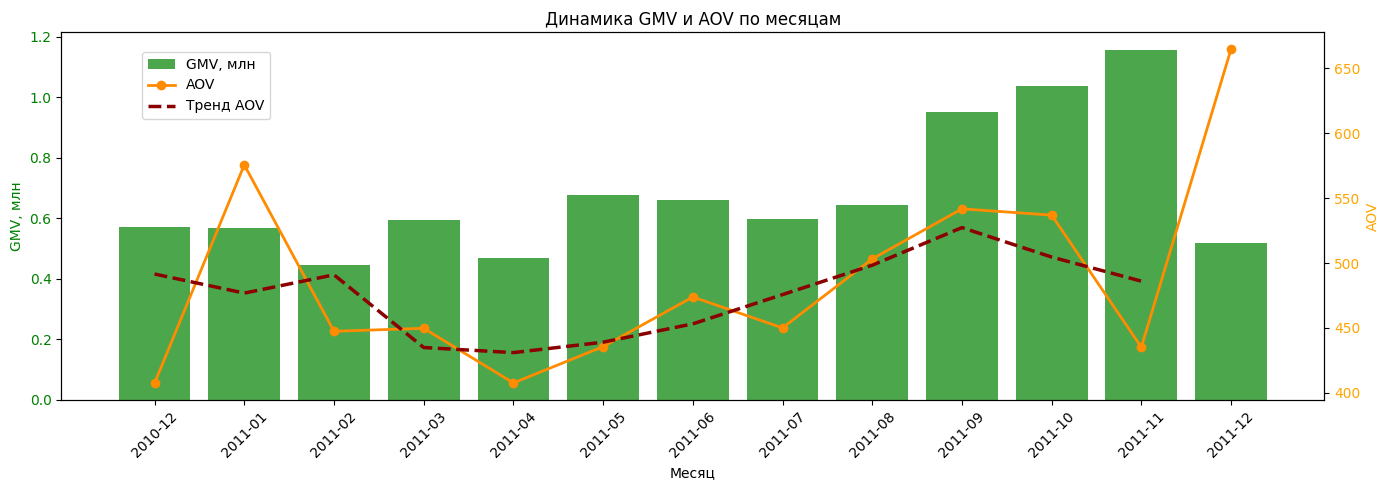

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly.index, monthly['GMV'] / 1000000, color='green', alpha=0.7, label='GMV, млн')
ax1.set_ylabel('GMV, млн', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Месяц')
ax1.set_title('Динамика GMV и AOV по месяцам')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['AOV'], color='darkorange', marker='o', linewidth=2, label='AOV')
ax2.set_ylabel('AOV', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

monthly['AOV_trend'] = monthly['AOV'][monthly.index < '2011-12'].rolling(window=3, center=True, min_periods=1).mean() 
ax2.plot(monthly.index, monthly['AOV_trend'], color='darkred', linewidth=2.5, linestyle='--', label='Тренд AOV')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

**Выводы из графика:**
- GMV стабильно начал расти в течение осени 2011 года — вероятно, сезонные распродажи. За это предположение в свою очередь говорит значительное падение среднего чека к ноябрю.
- Падение валовой стоимости в декабре того же года обусловленно недостатком данных за этот месяц.

- О резком росте AOV в декабре 2011 говорить нецелесообразно из-за недостатка данных. 
- Для расчёта тренда AOV я убрал декабрь 2011 года, чтобы он не искажал картину. Видно, что средний чек большую часть времени растёт, но наблюдаются колебания, похожие на сезонные - можно проанализировать в будущем.

*Интересные наблюдения:*
1. В январе 2011 года видим высокий средний чек при относительно низкой GMV, что, возможно, говорит о том, что на новогодние праздники были представлены дорогие товары, которые мало кто мог себе позволить.
2. В ноябре 2011 года наоборот видими рекорд по GMV при низком AOV, что в, свою очередь, может говорить о, как было сказано ранее, большой распродаже.
3. Несмотря на это, в целом наблюдается стабильность среднего чека.

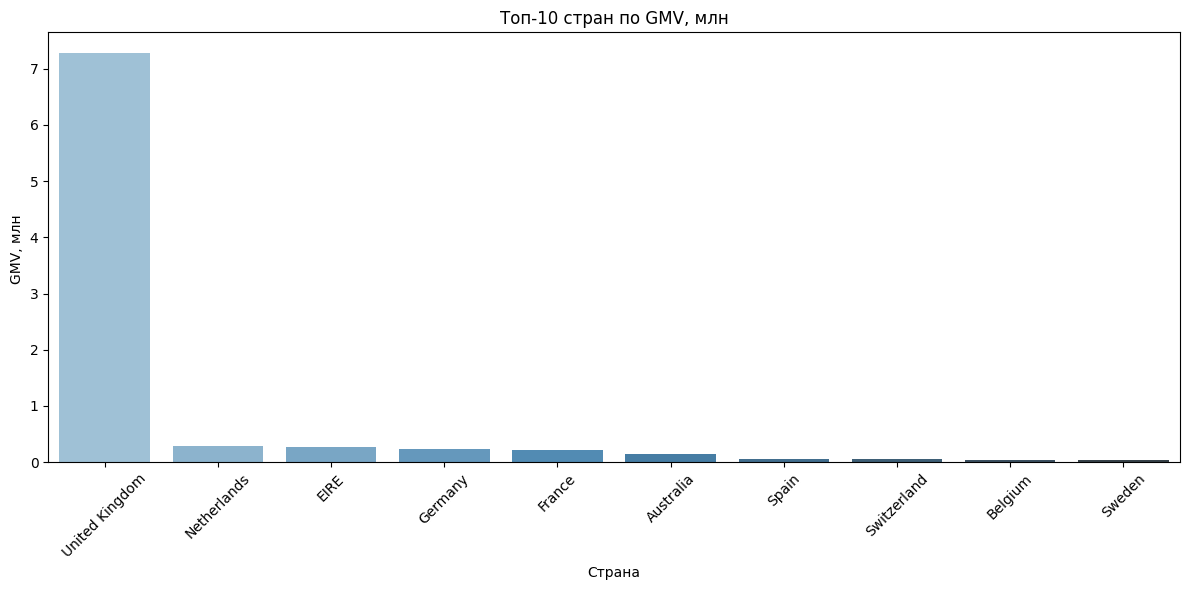

In [ ]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=country_revenue.index, y=country_revenue.values / 1000000, palette="Blues_d")
ax.set_title('Топ-10 стран по GMV, млн')
ax.set_ylabel('GMV, млн ')
ax.set_xlabel('Страна')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Доминирующий рынок - United Kingdom
- Даже визуально наблюдается огромная доля (больше 70%) представленности одной страны.

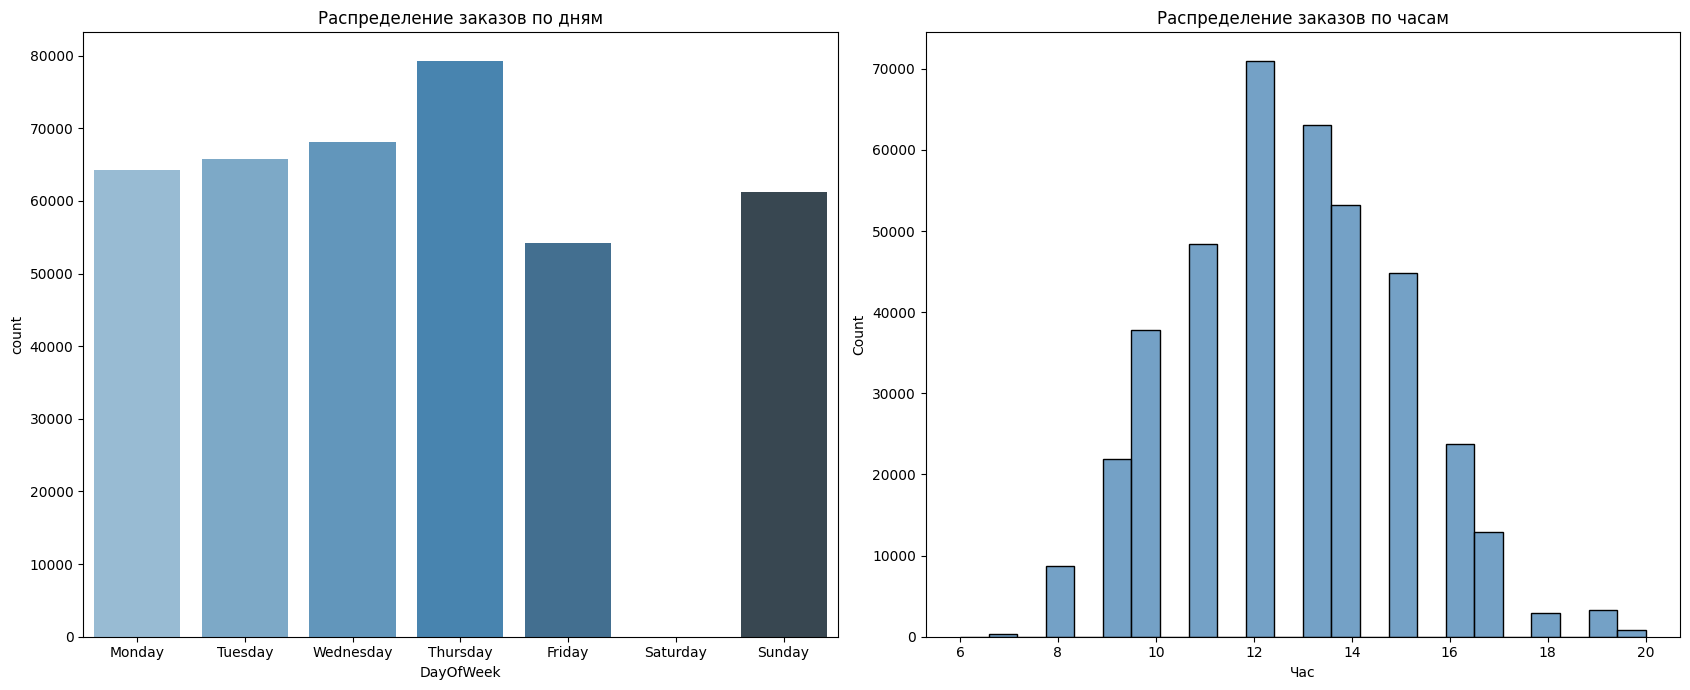

In [ ]:
(fig, (ax1, ax2)) = plt.subplots(1, 2, figsize=(17, 7))

# по дням недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='DayOfWeek', data=df_clean, order=day_order, palette='Blues_d', ax=ax1)
ax1.set_title('Распределение заказов по дням')
ax2.set_xlabel('')

# по часам
sns.histplot(df_clean['Hour'], bins=24, kde=False, color='steelblue', ax=ax2)
ax2.set_title('Распределение заказов по часам')
ax2.set_xlabel('Час')
plt.tight_layout()
plt.show()


**Выводы по графикам:**
- Нет данных за субботу, что, наверняка, связано со спецификой работы маркетплейса - видимо, по субботам он не работает - либо с ошибкой в предоставленных данных.
- Во втором графике в целом ничего удивительного - распределение частоты заказов по часам стремится к нормальному распределению. 

In [ ]:
df_clean.to_csv('data_clean.csv', index=False)
print(f'Очищенный файл сохранён!')

Очищенный файл сохранён!


**Дополнительные расчёты для вывода!**

In [ ]:
print(f"Выручка в % в UK: {df_clean[df_clean['Country'] == 'United Kingdom']['Revenue'].sum() / df_clean['Revenue'].sum() * 100}")

Выручка в % в UK: 81.97201990962903


## Итоги ##

**Что сделано:**
- Удалены дубликаты, возвраты, нулевые цены, строки без CustomerID.
- Созданы признаки: Revenue, YearMonth, DayOfWeek, Hour.
- Посчитаны базовые метрики: GMV, AOV, ARPU, количество заказов и клиентов.

**Ключевые инсайты:**
1. Бизнес сконцентрирован в UK (82% GMV).
2. Ноябрь 2011 показал аномальный рост — гипотеза: сезонная акция.
3. Средний чек стабилен, поэтому основной рычаг роста — количество клиентов.

**Ограничения данных:**
- Удалено ~25% строк из-за отсутствия CustomerID.
- Данные за декабрь 2011 неполные.

**Следующий шаг:** Когортный анализ и RFM-сегментация в `02_product_analysis.ipynb` и вывод по проделанной работе.